In [8]:
import io

import pandas as pd
import requests

In [2]:
# You might need this library to read Excel (or might not)
# !pip install xlrd

In [9]:
# data_url=''
# data_stream=requests.get(data_url).content

df = pd.read_csv('data/UCI_Credit_Card.csv')

#df=pd.read_excel('./default of credit card clients.xls', header=1, index_col=0)

# Maybe in a non-Unix system (e.g. Windows) this path doesn't work. Check with \ instead of /

In [15]:
df = df.rename(columns={'default.payment.next.month': 'target'})

In [11]:
df.shape


(30000, 25)

In [16]:
df.head()


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,target
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


In [17]:
df['target'].value_counts()




target
0    23364
1     6636
Name: count, dtype: int64

Step 2: Exploratory Data Analysis

In this section , i performed EDA for my better understanding of the dataset

In [18]:
df['target'].value_counts(normalize=True)

target
0    0.7788
1    0.2212
Name: proportion, dtype: float64

The class distribution confirms that the dataset is imbalanced, with a higher
proportion of non defaulting clients

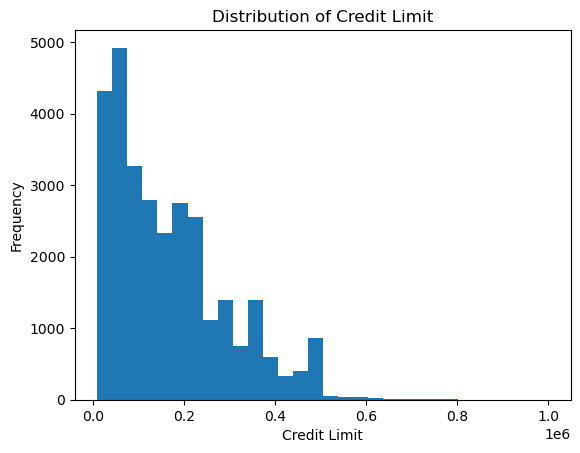

In [19]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df['LIMIT_BAL'], bins=30)
plt.xlabel('Credit Limit')
plt.ylabel('Frequency')
plt.title('Distribution of Credit Limit')
plt.show()

I focused on the credit limit because it reflects the amount of risk the bank takes for each client. The distribution is right skewed. 

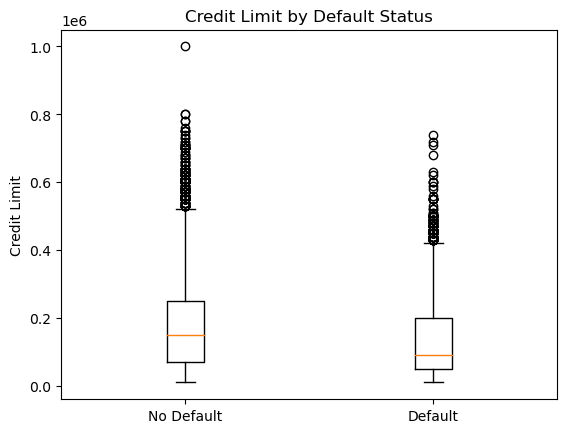

In [20]:
plt.figure()
plt.boxplot(
    [df[df['target']==0]['LIMIT_BAL'],
     df[df['target']==1]['LIMIT_BAL']],
     labels=['No Default', 'Default']
)
plt.ylabel('Credit Limit')
plt.title('Credit Limit by Default Status')
plt.show()

Clients who default, tend to have lower credit limits compared to non defaulting clients. Credit limit may be a useful feature for predicting default behavior

Step 3: Data Preprocessing and Train Test Split

In this section the dataset is being prepared by separating features and target variables, splitting the data into training and test sets and applying scaling where it was appropriate.

In [21]:
x = df.drop(columns=['target'])
y = df['target']

In [22]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y, 
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

The dataset is split into training and test sets using an 80/20 ratio. The class imbalance is preserved in both sets. A fixed random state is used to ensure reproducibility of the results.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

Feature scaling is applied to standarize the input variables. This is important for models like Logistic Regression, which are sensitive to the scale of input features.

Step 4: Models

In this section, different classification models are trained to predict credit card default. Multiple models are used in order to compare the performance and have a better understanding of their strengths and weaknesses.

In [24]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter = 1000)
log_reg.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Logistic Regression is used as a baseline model. This model helps provide a reference point to compare more complex models.

In [25]:
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(random_state=42)
tree.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

A Decision Tree is trained because it can capture non linear relationships between features. Its also easy to understand.

In [26]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

Random Forest is a model that combines multiple decision trees. It usually performs better than a single tree.

Step 5 

In this section, the traained models are evaluated using different performance metrics in order to compare their performance.

In [27]:
y_pred_log = log_reg.predict(x_test_scaled)
y_pred_tree = tree.predict(x_test)
y_pred_rf = rf.predict(x_test)

In [29]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

results = {
    'Model' : ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy' : [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    'F1-score' : [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ]
}
results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,F1-score
0,Logistic Regression,0.808333,0.357542
1,Decision Tree,0.725833,0.399854
2,Random Forest,0.814667,0.466411


Accuracy and F1-score are used to evaluate model performance. Accuracy shows overall correctness, while F1-score is more suitable for imbalanced datasets because it balances precision and recall

In [31]:
y_prob_log = log_reg.predict_proba(x_test_scaled)[:,1]
y_prob_rf = rf.predict_proba(x_test)[:,1]

roc_log = roc_auc_score(y_test, y_prob_log)
roc_rf = roc_auc_score(y_test, y_prob_rf)

roc_log, roc_rf

(0.7077224240780342, 0.7564438465548936)

The results show that more complex models in general perform better than the baseline Logistic Regression. Random Forest achieves the strongest overall performance, specificaly in terms of F1-score and ROC-AUC, showing us a better handling of class imbalance

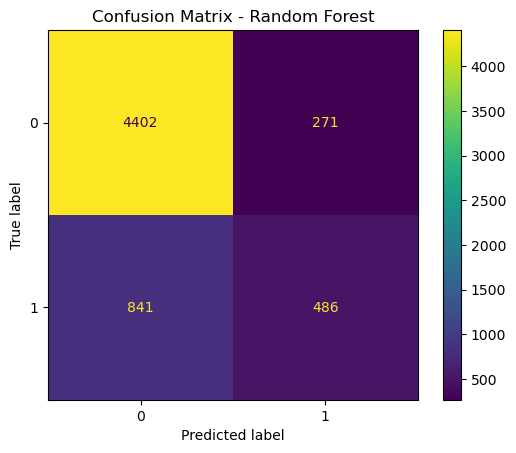

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Confusion Matrix - Random Forest")
plt.show()

The confusion matrix for the Random Forest model shows how predictions are distributed across default and non default classes. This helps us better understand the types of errors made by the model.

Step 6

In this assignment, several machine learning models were trained to predict credit card default. As seen above exploratory data analysis showed that the dataset is imbalanced and that credit limit is an importand feature to default behavior.

Among the tested models, Random Forest achieved the best overall performance, especially in F1-score and ROC-AUC. This shows that ensemble methods are better suited for this task compared to models such as Logistic Regression.

Overall the results show that machine learning models can be effective in predicting credit card default.